### Basic Chat BOT

with langgraph - Graph API

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv


load_dotenv()
my_groq_api = os.getenv("GROQ_API_KEY")

if not my_groq_api:
    raise ValueError("API key not found")


In [8]:
from langchain_groq import  ChatGroq
from langchain.chat_models import init_chat_model



# model="llama-3.3-70b-versatile"
model="openai/gpt-oss-120b"
llm = ChatGroq(model=model)

llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.2'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x112f18a50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x112f19450>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [9]:

from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph
from langgraph.graph import add_messages

class State(TypedDict):
    messages:Annotated[list, add_messages]


In [10]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [11]:
from langgraph.graph import StateGraph, START, END

graph_builder=StateGraph(State)

graph_builder.add_node("llmchatbot", chatbot)

graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

graph = graph_builder.compile()


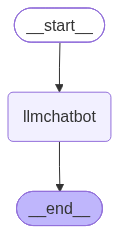

In [15]:
## visiualize the graph

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [15]:
res = graph.invoke({"messages":"hii"})

res["messages"][-1].content

'Hi there! How can I help you today?'

In [18]:
for event in graph.stream({"messages" : "write 1000 words paragraph on clouds?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Clouds, those ever‑shifting, vaporous formations that drift across the sky, have fascinated humanity since the earliest days of myth and observation, serving simultaneously as subjects of scientific inquiry, artistic inspiration, navigational aids, and cultural symbols, and their complex nature can be explored through an interdisciplinary lens that encompasses atmospheric physics, meteorology, climatology, ecology, literature, and even philosophy, for clouds are not merely collections of water droplets or ice crystals suspended in the troposphere but dynamic, multi‑scale systems that embody the intricate interplay of thermodynamics, fluid dynamics, radiation, and microphysical processes, beginning with the fundamental principle that air, when warmed at the Earth’s surface, becomes less dense and rises in buoyant parcels, expanding and cooling adiabatically as it ascends, and when the temperature of this rising air falls to its dew point, the water vapor it contains condenses onto micro